# Function 8 — GP vs GBM vs GP+GBM Ensemble Surrogate Comparison (Weeks 4–5)

**Purpose:** Evaluate Gradient Boosting (GBM) as an alternative or complement to the Gaussian Process surrogate for Function 8.

Three surrogate strategies are compared:
1. **Baseline GP** — Matérn 5/2 with ARD, standardised Y (current production surrogate)
2. **GBM standalone** — GradientBoostingRegressor with bootstrap uncertainty (quantile-style)
3. **GP + GBM ensemble** — GBM captures the global non-linear trend; a residual GP models the remaining local structure with calibrated posterior uncertainty

**Function 8 context:**
- 8D input, all dimensions in [0, 1] — highest dimensionality function in the challenge
- Described as an ML hyperparameter optimisation problem
- 40 initial observations + 4 portal submissions (W4 pending)
- Best result: W2 Y = 9.7035 at D1=0.212, D2=0.204, D3=0.040, D4=0.040, D5=0.973, D6=0.067, D7=0.219, D8=0.061
- W3 failure (7.318): D2=0.956, D4=0.908 — both too high
- Key prior finding: **D1 and D3 must stay LOW** (r ≈ −0.62 with Y)

---

## ► ENTER WEEK 4 RESULT HERE before running

Set `WEEK4_Y` once the portal returns the W4 score. Leave as `None` to run on W1–W3 data only.

In [1]:
# ── EDIT THIS CELL WHEN YOU RECEIVE THE WEEK 4 RESULT ──────────────────────
WEEK4_Y = None
# e.g. WEEK4_Y = 9.821
# ────────────────────────────────────────────────────────────────────────────

In [2]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, pearsonr

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
    'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
    'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b', 'ytick.color': '#64748b',
    'font.family': 'monospace', 'axes.titlesize': 11,
})

COLORS = {
    'gp':      '#00d4ff',
    'gbm':     '#f59e0b',
    'ensemble':'#7c3aed',
    'init':    '#475569',
    'portal':  '#06b6d4',
    'best':    '#f59e0b',
    'suggest': '#00d4ff',
    'zero':    '#ef4444',
}

DIM_LABELS = [
    'D1: param1', 'D2: param2', 'D3: param3', 'D4: param4',
    'D5: param5', 'D6: param6', 'D7: param7', 'D8: param8',
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Assemble Dataset

In [3]:
X_init = np.load('../initial_data/function_8/initial_inputs.npy')
Y_init = np.load('../initial_data/function_8/initial_outputs.npy').ravel()

with open('../capstone_history.json') as f:
    h8 = json.load(f)['8']

X_portal_all = np.array(h8['X'], dtype=np.float64) if h8['X'] else np.empty((0, 8))
Y_portal_all = np.array(h8['Y'], dtype=np.float64) if h8['Y'] else np.empty(0)

# Apply W4 override or drop pending (Y == 0) submissions
portal_mask = Y_portal_all != 0
if WEEK4_Y is not None and len(Y_portal_all) >= 4:
    Y_portal_all[3] = float(WEEK4_Y)
    portal_mask[3] = True
    print(f'Week 4 result applied: Y = {WEEK4_Y}')
else:
    n_pending = int((~portal_mask).sum())
    if n_pending:
        print(f'Note: {n_pending} portal submission(s) with Y=0 excluded (pending).')

X_portal = X_portal_all[portal_mask]
Y_portal = Y_portal_all[portal_mask]

X_all = np.vstack([X_init, X_portal])
Y_all = np.concatenate([Y_init, Y_portal])
N_INIT   = len(X_init)
N_PORTAL = len(X_portal)

best_idx = int(np.argmax(Y_all))
best_x   = X_all[best_idx].copy()
best_y   = Y_all[best_idx]

# Standardise Y for surrogate fitting (matches production pipeline)
Y_mean = Y_all.mean()
Y_std  = max(Y_all.std(), 1e-8)
Y_fit  = (Y_all - Y_mean) / Y_std

print(f'\nInitial data:   {N_INIT} points')
print(f'Portal obs:     {N_PORTAL} points')
print(f'Combined total: {len(X_all)} points')
print(f'Y range:        [{Y_all.min():.4f}, {Y_all.max():.4f}]')
print(f'Y_fit range:    [{Y_fit.min():.3f}, {Y_fit.max():.3f}]  (z-scored)')
print(f'\nBest Y:  {best_y:.6f}')
print(f'Best X:  {[round(v,4) for v in best_x.tolist()]}')
print(f'Source:  {"Portal W"+str(best_idx-N_INIT+1) if best_idx >= N_INIT else "Initial data"}')

Note: 1 portal submission(s) with Y=0 excluded (pending).

Initial data:   40 points
Portal obs:     3 points
Combined total: 43 points
Y range:        [5.5922, 9.7035]
Y_fit range:    [-2.328, 1.853]  (z-scored)

Best Y:  9.703542
Best X:  [0.2117, 0.2041, 0.0404, 0.0403, 0.9727, 0.0667, 0.2193, 0.0611]
Source:  Portal W2


## 2. Baseline GP (Matérn 5/2, ARD)

Fits the production surrogate to provide a reference R² and next-query suggestion.
Five-fold CV is used rather than LOO to keep computation tractable with 8D ARD and 5 restarts.

In [4]:
def build_ard_gp(n_restarts=5):
    ls = np.ones(8)
    kernel = C(1.0) * Matern(length_scale=ls, nu=2.5, length_scale_bounds=(1e-2, 10.0))
    return GaussianProcessRegressor(
        kernel=kernel, alpha=1e-6,
        normalize_y=False,   # Y_fit is already z-scored
        n_restarts_optimizer=n_restarts,
    )

# 5-fold CV on standardised Y
gp_base = build_ard_gp(n_restarts=2)   # fewer restarts for CV speed
kf = KFold(n_splits=5, shuffle=True, random_state=42)
gp_cv_scores = cross_val_score(gp_base, X_all, Y_fit, cv=kf, scoring='r2')
print(f'GP 5-fold CV R²:  {gp_cv_scores.mean():.4f} ± {gp_cv_scores.std():.4f}')

# Full fit for predictions and ARD inspection
gp_full = build_ard_gp(n_restarts=5)
gp_full.fit(X_all, Y_fit)

# ARD length-scales — shorter = more sensitive dimension
opt_kernel = gp_full.kernel_
ls_values  = opt_kernel.k2.length_scale
ls_series  = pd.Series(ls_values, index=DIM_LABELS, name='GP length-scale')
print('\nGP ARD optimised length-scales (shorter = more important):')
print(ls_series.round(4).sort_values())

GP 5-fold CV R²:  0.9685 ± 0.0207

GP ARD optimised length-scales (shorter = more important):
D3: param3     2.1928
D7: param7     3.1292
D1: param1     3.1559
D6: param6     4.1162
D2: param2     4.3020
D4: param4    10.0000
D5: param5    10.0000
D8: param8    10.0000
Name: GP length-scale, dtype: float64


In [5]:
# GP next-query suggestion via UCB (beta=2.5, matching production config)
BETA = 2.5
N_CAND = 8000
rng = np.random.default_rng(0)

candidates = rng.uniform(0, 1, (N_CAND, 8))
gp_mean, gp_std = gp_full.predict(candidates, return_std=True)
gp_acq = gp_mean + BETA * gp_std
gp_best_cand = int(np.argmax(gp_acq))
GP_SUGGEST = candidates[gp_best_cand].copy()

gp_pred_best = float(gp_mean[gp_best_cand]) * Y_std + Y_mean
gp_std_best  = float(gp_std[gp_best_cand])  * Y_std

print(f'GP UCB (β={BETA}) suggestion:')
print(f'  X = {[round(v,4) for v in GP_SUGGEST.tolist()]}')
print(f'  GP mean (original scale) = {gp_pred_best:.4f}')
print(f'  GP std  (original scale) = {gp_std_best:.4f}')

GP UCB (β=2.5) suggestion:
  X = [0.0215, 0.0382, 0.2339, 0.2738, 0.8266, 0.904, 0.1623, 0.018]
  GP mean (original scale) = 9.8916
  GP std  (original scale) = 0.2117


## 3. GBM Surrogate

### 3a. Model fitting and LOO cross-validation

With n=43 points we must regularise aggressively to avoid overfitting:
- `max_depth=3` — shallow trees capture first-order interactions without memorising
- `learning_rate=0.05` — slow gradient updates generalise better
- `subsample=0.8` — stochastic gradient boosting reduces variance
- `min_samples_leaf=3` — prevents leaf nodes on single outlier points

LOO cross-validation is used (fast for GBM, no probabilistic fitting overhead).

In [6]:
GBM_PARAMS = dict(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
)

gbm_base = GradientBoostingRegressor(**GBM_PARAMS)

# LOO CV on standardised Y
loo = LeaveOneOut()
y_loo_gbm = np.zeros(len(Y_fit))
for train_idx, test_idx in loo.split(X_all):
    gbm_cv = GradientBoostingRegressor(**GBM_PARAMS)
    gbm_cv.fit(X_all[train_idx], Y_fit[train_idx])
    y_loo_gbm[test_idx] = gbm_cv.predict(X_all[test_idx])

gbm_loo_r2  = r2_score(Y_fit, y_loo_gbm)
gbm_loo_mse = mean_squared_error(Y_fit, y_loo_gbm)
print(f'GBM LOO R²:  {gbm_loo_r2:.4f}')
print(f'GBM LOO MSE: {gbm_loo_mse:.4f}  (z-score² units)')

# Full fit for predictions
gbm_full = GradientBoostingRegressor(**GBM_PARAMS)
gbm_full.fit(X_all, Y_fit)
print('\nGBM full model fitted.')

GBM LOO R²:  0.7978
GBM LOO MSE: 0.2022  (z-score² units)

GBM full model fitted.


### 3b. Bootstrap uncertainty for GBM

GBM has no built-in posterior. We estimate prediction uncertainty by training 30 GBMs on bootstrap resamples and taking the standard deviation of their predictions. This gives a rough but useful uncertainty map for UCB-style acquisition.

In [7]:
N_BOOT = 30
rng_boot = np.random.default_rng(99)

boot_preds = np.zeros((N_BOOT, N_CAND))
for b in range(N_BOOT):
    idx = rng_boot.integers(0, len(X_all), len(X_all))
    gbm_b = GradientBoostingRegressor(**GBM_PARAMS)
    gbm_b.fit(X_all[idx], Y_fit[idx])
    boot_preds[b] = gbm_b.predict(candidates)

gbm_mean = gbm_full.predict(candidates)         # deterministic mean from full model
gbm_std  = boot_preds.std(axis=0)               # bootstrap std as uncertainty proxy

gbm_acq  = gbm_mean + BETA * gbm_std
gbm_best_cand = int(np.argmax(gbm_acq))
GBM_SUGGEST = candidates[gbm_best_cand].copy()

gbm_pred_best = float(gbm_mean[gbm_best_cand]) * Y_std + Y_mean
gbm_std_best  = float(gbm_std[gbm_best_cand])  * Y_std

print(f'GBM UCB (β={BETA}) suggestion:')
print(f'  X = {[round(v,4) for v in GBM_SUGGEST.tolist()]}')
print(f'  GBM mean (original scale) = {gbm_pred_best:.4f}')
print(f'  GBM boot-std (orig scale) = {gbm_std_best:.4f}')

GBM UCB (β=2.5) suggestion:
  X = [0.3385, 0.2045, 0.15, 0.0428, 0.7252, 0.5187, 0.096, 0.1281]
  GBM mean (original scale) = 9.6361
  GBM boot-std (orig scale) = 0.3569


### 3c. Feature importance

Two measures are compared:
- **Native importance** — total impurity reduction across all splits on each feature
- **Permutation importance** — drop in R² when each feature's values are randomly shuffled

Permutation importance on the training set is biased toward features that the model uses for memorisation. LOO permutation importance would be cleaner but is expensive. Both measures are shown for comparison.

In [8]:
# Native feature importance
native_imp = gbm_full.feature_importances_

# Permutation importance on full training set
perm_result = permutation_importance(
    gbm_full, X_all, Y_fit,
    n_repeats=20, random_state=42, scoring='r2',
)
perm_imp  = perm_result.importances_mean
perm_std  = perm_result.importances_std

imp_df = pd.DataFrame({
    'Dimension':   DIM_LABELS,
    'Native':      native_imp.round(4),
    'Permutation': perm_imp.round(4),
    'Perm std':    perm_std.round(4),
    'GP inv-ls':   (1.0 / ls_values).round(4),   # higher = shorter ls = more important
}).sort_values('Permutation', ascending=False)

print('Feature importance comparison (sorted by permutation importance):')
print(imp_df.to_string(index=False))

Feature importance comparison (sorted by permutation importance):
 Dimension  Native  Permutation  Perm std  GP inv-ls
D3: param3  0.2620       0.3859    0.0703     0.4560
D1: param1  0.2256       0.2967    0.0452     0.3169
D7: param7  0.1648       0.1612    0.0302     0.3196
D2: param2  0.0908       0.0808    0.0098     0.2324
D4: param4  0.0916       0.0436    0.0076     0.1000
D8: param8  0.0658       0.0128    0.0029     0.1000
D5: param5  0.0672       0.0092    0.0014     0.1000
D6: param6  0.0321       0.0088    0.0021     0.2429


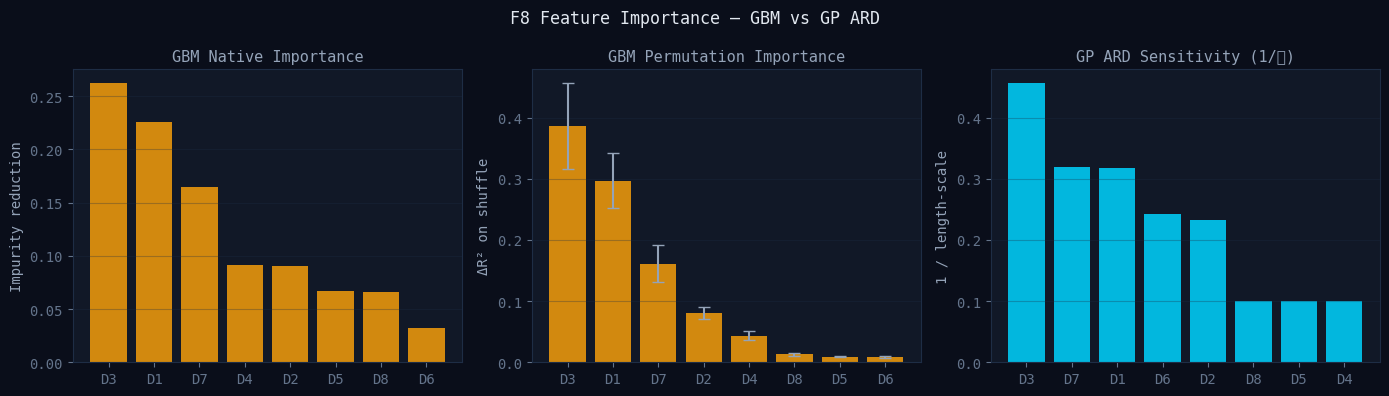

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('F8 Feature Importance — GBM vs GP ARD', color='#e2e8f0', fontsize=12)

short_labels = [f'D{i+1}' for i in range(8)]

# Native GBM importance
order = np.argsort(native_imp)[::-1]
axes[0].bar(range(8), native_imp[order], color=COLORS['gbm'], alpha=0.85)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels([short_labels[i] for i in order])
axes[0].set_title('GBM Native Importance', color='#94a3b8')
axes[0].set_ylabel('Impurity reduction', color='#94a3b8')

# Permutation importance with error bars
perm_order = np.argsort(perm_imp)[::-1]
axes[1].bar(range(8), perm_imp[perm_order], yerr=perm_std[perm_order],
            color=COLORS['gbm'], alpha=0.85, capsize=4, error_kw={'ecolor': '#94a3b8'})
axes[1].set_xticks(range(8))
axes[1].set_xticklabels([short_labels[i] for i in perm_order])
axes[1].set_title('GBM Permutation Importance', color='#94a3b8')
axes[1].set_ylabel('ΔR² on shuffle', color='#94a3b8')

# GP ARD 1/length-scale (higher = shorter = more sensitive)
inv_ls = 1.0 / ls_values
ls_order = np.argsort(inv_ls)[::-1]
axes[2].bar(range(8), inv_ls[ls_order], color=COLORS['gp'], alpha=0.85)
axes[2].set_xticks(range(8))
axes[2].set_xticklabels([short_labels[i] for i in ls_order])
axes[2].set_title('GP ARD Sensitivity (1/ℓ)', color='#94a3b8')
axes[2].set_ylabel('1 / length-scale', color='#94a3b8')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. GP + GBM Residual Ensemble

### Rationale

A pure GP in 8D with 43 points often struggles to fit both the global trend and the local structure simultaneously. A **two-stage model** separates these concerns:

1. **Stage 1 — GBM global trend:** `f̂_GBM(x)` — captures non-linear main effects and low-order interactions
2. **Stage 2 — Residual GP:** `ε(x) = Y_fit − f̂_GBM(x)`, fitted with a GP

The ensemble prediction at any new point `x*` is:
```
μ_ens(x*) = f̂_GBM(x*) + μ_GP_res(x*)
σ_ens(x*) = σ_GP_res(x*)   ← calibrated posterior from the residual GP
```

**Key advantage:** the residual GP only needs to model the *remaining* variance after GBM has explained the main effects. With less variance to explain, the GP fits better on a small dataset and its uncertainty estimates become more reliable.

In [10]:
# Stage 1: GBM in-sample predictions (train on all data, predict training set)
# Note: in-sample GBM predictions have near-zero residuals unless regularised —
# this is correct; the GP will see small residuals on well-fitted regions and
# larger ones where GBM generalises poorly.
gbm_train_pred = gbm_full.predict(X_all)   # in z-score units
residuals = Y_fit - gbm_train_pred

print(f'GBM in-sample R²:      {r2_score(Y_fit, gbm_train_pred):.4f}')
print(f'Residual variance:     {residuals.var():.4f}  (z-score² units)')
print(f'Residual range:        [{residuals.min():.3f}, {residuals.max():.3f}]')
print(f'Original Y_fit range:  [{Y_fit.min():.3f}, {Y_fit.max():.3f}]')
print(f'Variance fraction remaining: {residuals.var() / Y_fit.var():.3f}')

GBM in-sample R²:      0.9995
Residual variance:     0.0005  (z-score² units)
Residual range:        [-0.074, 0.047]
Original Y_fit range:  [-2.328, 1.853]
Variance fraction remaining: 0.001


In [11]:
# Stage 2: fit GP on residuals
# Use isotropic Matern (residuals have less structure than raw Y; ARD may overfit
# on residual noise with only 43 points)
def build_residual_gp(n_restarts=5):
    kernel = C(0.5) * Matern(length_scale=np.ones(8) * 0.5, nu=2.5,
                              length_scale_bounds=(1e-2, 5.0))
    return GaussianProcessRegressor(
        kernel=kernel, alpha=1e-4,
        normalize_y=True,   # residuals may not be zero-mean
        n_restarts_optimizer=n_restarts,
    )

gp_res = build_residual_gp()
gp_res.fit(X_all, residuals)

# In-sample check: ensemble = GBM_pred + GP_residual_mean
res_mean_train, _ = gp_res.predict(X_all, return_std=True)
ensemble_train = gbm_train_pred + res_mean_train
print(f'Ensemble in-sample R²: {r2_score(Y_fit, ensemble_train):.4f}')

Ensemble in-sample R²: 1.0000


### 4b. LOO cross-validation for the ensemble

For a fair comparison, both stages (GBM + residual GP) are refitted for each LOO fold.

In [12]:
y_loo_ens = np.zeros(len(Y_fit))

for train_idx, test_idx in loo.split(X_all):
    # Stage 1: GBM on training fold
    gbm_loo_e = GradientBoostingRegressor(**GBM_PARAMS)
    gbm_loo_e.fit(X_all[train_idx], Y_fit[train_idx])

    # Stage 2: compute training residuals and fit residual GP
    res_train = Y_fit[train_idx] - gbm_loo_e.predict(X_all[train_idx])
    gp_loo_e = build_residual_gp(n_restarts=2)
    gp_loo_e.fit(X_all[train_idx], res_train)

    # Ensemble prediction on test point
    gbm_test_pred = gbm_loo_e.predict(X_all[test_idx])
    gp_res_pred   = gp_loo_e.predict(X_all[test_idx])
    y_loo_ens[test_idx] = gbm_test_pred + gp_res_pred

ens_loo_r2  = r2_score(Y_fit, y_loo_ens)
ens_loo_mse = mean_squared_error(Y_fit, y_loo_ens)
print(f'Ensemble LOO R²:  {ens_loo_r2:.4f}')
print(f'Ensemble LOO MSE: {ens_loo_mse:.4f}  (z-score² units)')

Ensemble LOO R²:  0.7976
Ensemble LOO MSE: 0.2024  (z-score² units)


### 4c. Ensemble next-query suggestion

In [13]:
# Ensemble predictions on candidate set
gbm_cand_pred  = gbm_full.predict(candidates)          # GBM global trend
res_cand_mean, res_cand_std = gp_res.predict(candidates, return_std=True)   # residual GP

ens_mean = gbm_cand_pred + res_cand_mean
ens_std  = res_cand_std                    # uncertainty from the residual GP

ens_acq  = ens_mean + BETA * ens_std
ens_best_cand = int(np.argmax(ens_acq))
ENS_SUGGEST = candidates[ens_best_cand].copy()

ens_pred_best = float(ens_mean[ens_best_cand]) * Y_std + Y_mean
ens_std_best  = float(ens_std[ens_best_cand])  * Y_std

print(f'Ensemble UCB (β={BETA}) suggestion:')
print(f'  X = {[round(v,4) for v in ENS_SUGGEST.tolist()]}')
print(f'  Ensemble mean (orig scale) = {ens_pred_best:.4f}')
print(f'  Residual GP std (orig)     = {ens_std_best:.4f}')

Ensemble UCB (β=2.5) suggestion:
  X = [0.3385, 0.2045, 0.15, 0.0428, 0.7252, 0.5187, 0.096, 0.1281]
  Ensemble mean (orig scale) = 9.6459
  Residual GP std (orig)     = 0.0189


## 5. Three-Way Surrogate Comparison

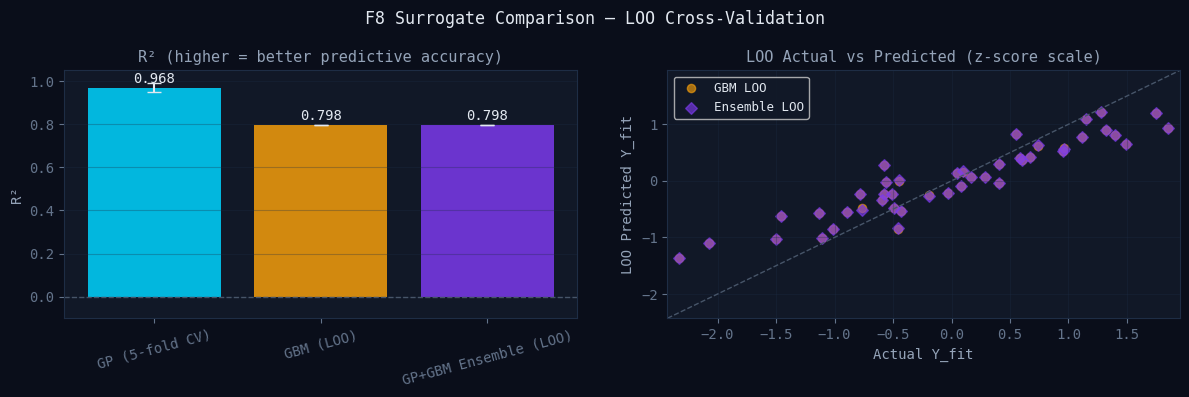

In [14]:
# ----- LOO / CV R² comparison bar chart -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('F8 Surrogate Comparison — LOO Cross-Validation', color='#e2e8f0', fontsize=12)

models       = ['GP (5-fold CV)', 'GBM (LOO)', 'GP+GBM Ensemble (LOO)']
r2_scores    = [gp_cv_scores.mean(), gbm_loo_r2, ens_loo_r2]
r2_errs      = [gp_cv_scores.std(),  0,          0]
model_colors = [COLORS['gp'], COLORS['gbm'], COLORS['ensemble']]

bars = axes[0].bar(models, r2_scores, color=model_colors, alpha=0.85)
axes[0].errorbar(models, r2_scores, yerr=r2_errs, fmt='none',
                 ecolor='#e2e8f0', capsize=5)
axes[0].axhline(0, color='#475569', lw=1, ls='--')
axes[0].set_title('R² (higher = better predictive accuracy)', color='#94a3b8')
axes[0].set_ylabel('R²', color='#94a3b8')
axes[0].set_ylim(-0.1, 1.05)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=10, color='#e2e8f0')

# ----- LOO residual scatter for GBM and ensemble -----
axes[1].scatter(Y_fit, y_loo_gbm,  alpha=0.65, s=35, color=COLORS['gbm'],      label='GBM LOO')
axes[1].scatter(Y_fit, y_loo_ens,  alpha=0.65, s=35, color=COLORS['ensemble'], label='Ensemble LOO', marker='D')
lims = [min(Y_fit.min(), y_loo_gbm.min(), y_loo_ens.min()) - 0.1,
        max(Y_fit.max(), y_loo_gbm.max(), y_loo_ens.max()) + 0.1]
axes[1].plot(lims, lims, '--', color='#475569', lw=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Actual Y_fit', color='#94a3b8')
axes[1].set_ylabel('LOO Predicted Y_fit', color='#94a3b8')
axes[1].set_title('LOO Actual vs Predicted (z-score scale)', color='#94a3b8')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ----- Predictions at key points -----
KEY_POINTS = {
    'Initial best':   X_all[np.argmax(Y_init)],
    'W1 submission':  X_portal_all[0] if len(X_portal_all) > 0 else None,
    'W2 submission':  X_portal_all[1] if len(X_portal_all) > 1 else None,
    'W3 submission':  X_portal_all[2] if len(X_portal_all) > 2 else None,
    'Best known (W2)': best_x,
}
KEY_POINTS = {k: v for k, v in KEY_POINTS.items() if v is not None}

print(f'{"Point":<25} {"Actual Y":>10} {"GP mean":>10} {"GBM mean":>10} {"Ens mean":>10}')
print('-' * 70)

for label, x in KEY_POINTS.items():
    xq = x.reshape(1, -1)
    # Find actual Y (closest training point)
    dists = np.sum((X_all - x)**2, axis=1)
    actual_y = Y_all[np.argmin(dists)]

    gp_m  = float(gp_full.predict(xq)[0])  * Y_std + Y_mean
    gbm_m = float(gbm_full.predict(xq)[0]) * Y_std + Y_mean
    gp_r  = float(gp_res.predict(xq)[0])
    ens_m = (float(gbm_full.predict(xq)[0]) + gp_r) * Y_std + Y_mean

    print(f'{label:<25} {actual_y:>10.4f} {gp_m:>10.4f} {gbm_m:>10.4f} {ens_m:>10.4f}')

Point                       Actual Y    GP mean   GBM mean   Ens mean
----------------------------------------------------------------------
Initial best                  9.5985     9.5985     9.6133     9.5985
W1 submission                 9.2597     9.2597     9.2507     9.2597
W2 submission                 9.7035     9.7035     9.7013     9.7035
W3 submission                 7.3179     7.3179     7.3504     7.3179
Best known (W2)               9.7035     9.7035     9.7013     9.7035


In [16]:
# ----- Next-query suggestion comparison -----
print('Next-query suggestion comparison (UCB, β=2.5)\n')
print(f'{"Surrogate":<25} {"Predicted Y":>12} {"GP std":>10}')
print('-' * 50)
print(f'{"GP (ARD)":<25} {gp_pred_best:>12.4f} {gp_std_best:>10.4f}')
print(f'{"GBM (bootstrap)":<25} {gbm_pred_best:>12.4f} {gbm_std_best:>10.4f}')
print(f'{"GP+GBM Ensemble":<25} {ens_pred_best:>12.4f} {ens_std_best:>10.4f}')
print()
print('Suggestions (rounded to 4 d.p.):')
print(f'{"":<5}  {"D1":>6} {"D2":>6} {"D3":>6} {"D4":>6} {"D5":>6} {"D6":>6} {"D7":>6} {"D8":>6}')
print(f'{"GP":<5}  {", ".join(f"{v:.4f}" for v in GP_SUGGEST)}')
print(f'{"GBM":<5}  {", ".join(f"{v:.4f}" for v in GBM_SUGGEST)}')
print(f'{"Ens":<5}  {", ".join(f"{v:.4f}" for v in ENS_SUGGEST)}')
print(f'\nKnown best (W2): {", ".join(f"{v:.4f}" for v in best_x)}')

Next-query suggestion comparison (UCB, β=2.5)

Surrogate                  Predicted Y     GP std
--------------------------------------------------
GP (ARD)                        9.8916     0.2117
GBM (bootstrap)                 9.6361     0.3569
GP+GBM Ensemble                 9.6459     0.0189

Suggestions (rounded to 4 d.p.):
           D1     D2     D3     D4     D5     D6     D7     D8
GP     0.0215, 0.0382, 0.2339, 0.2738, 0.8266, 0.9040, 0.1623, 0.0180
GBM    0.3385, 0.2045, 0.1500, 0.0428, 0.7252, 0.5187, 0.0960, 0.1281
Ens    0.3385, 0.2045, 0.1500, 0.0428, 0.7252, 0.5187, 0.0960, 0.1281

Known best (W2): 0.2117, 0.2041, 0.0404, 0.0403, 0.9727, 0.0667, 0.2193, 0.0611


## 6. Dimension Analysis — 1D Slices Through Best Point

For each of the 8 dimensions, the three surrogates are evaluated along a 1D slice through the current best point (W2). This reveals how each model interprets the response surface and whether GBM captures non-linearity that the GP misses.

Dimensions are ordered by GBM permutation importance (most influential first).

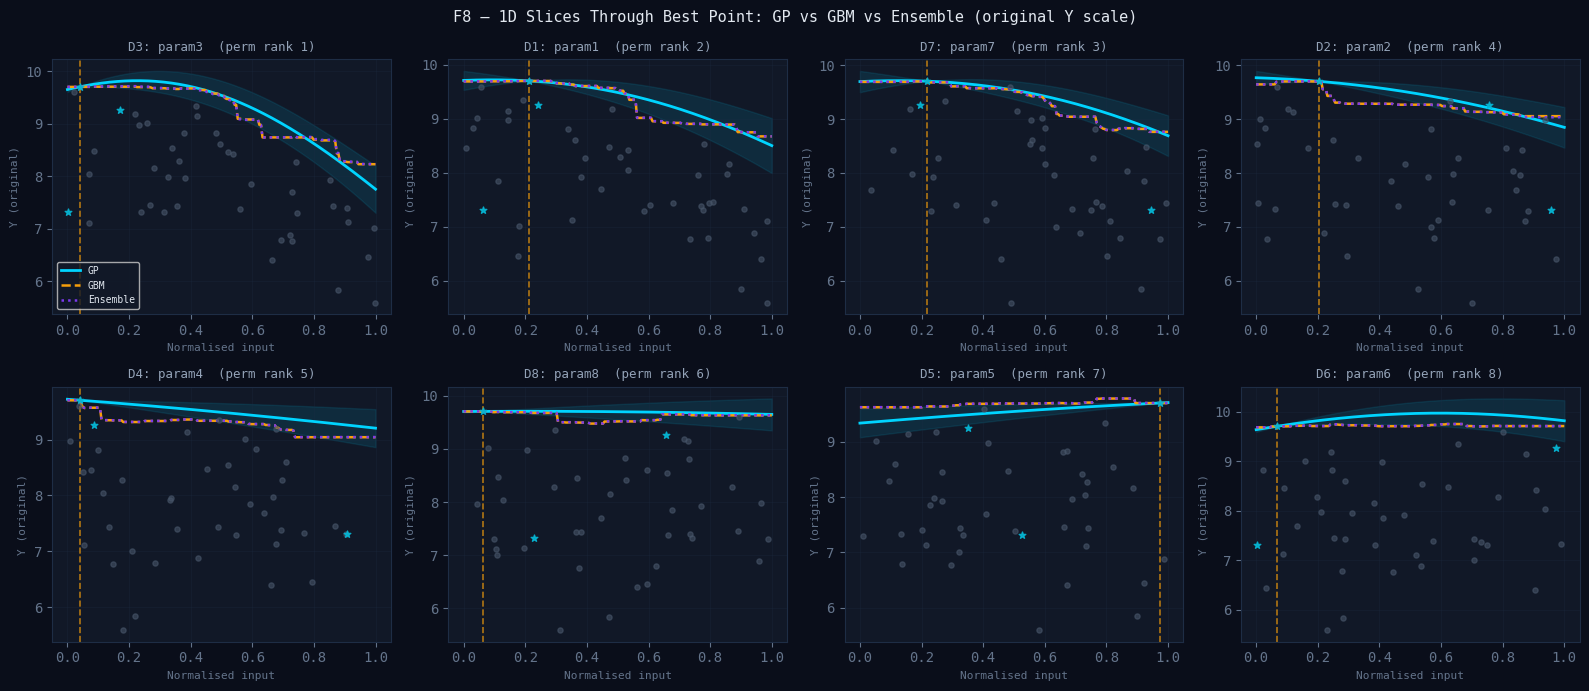

In [17]:
dim_order = np.argsort(perm_imp)[::-1]   # most important first
t = np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('F8 — 1D Slices Through Best Point: GP vs GBM vs Ensemble (original Y scale)',
             color='#e2e8f0', fontsize=11)
axes = axes.ravel()

for plot_idx, dim in enumerate(dim_order):
    ax = axes[plot_idx]
    slice_X = np.tile(best_x, (200, 1))
    slice_X[:, dim] = t

    # GP
    gp_m, gp_s = gp_full.predict(slice_X, return_std=True)
    gp_m = gp_m * Y_std + Y_mean
    gp_s = gp_s * Y_std

    # GBM
    gbm_m = gbm_full.predict(slice_X) * Y_std + Y_mean

    # Ensemble
    ens_m_raw = gbm_full.predict(slice_X) + gp_res.predict(slice_X)
    ens_m = ens_m_raw * Y_std + Y_mean

    ax.plot(t, gp_m,  color=COLORS['gp'],       lw=2.0, label='GP')
    ax.fill_between(t, gp_m - 2*gp_s, gp_m + 2*gp_s,
                    color=COLORS['gp'], alpha=0.10)
    ax.plot(t, gbm_m, color=COLORS['gbm'],       lw=1.8, ls='--', label='GBM')
    ax.plot(t, ens_m, color=COLORS['ensemble'],  lw=1.8, ls=':',  label='Ensemble')

    # Mark best point
    ax.axvline(best_x[dim], color=COLORS['best'], lw=1.2, ls='--', alpha=0.7)

    # Training data projected onto this dimension
    ax.scatter(X_all[:N_INIT, dim], Y_init, s=14, color=COLORS['init'],   alpha=0.6, zorder=3)
    ax.scatter(X_portal[:, dim],    Y_portal, s=25, color=COLORS['portal'], alpha=0.9, zorder=4,
               marker='*')

    ax.set_title(f'{DIM_LABELS[dim]}  (perm rank {plot_idx+1})', color='#94a3b8', fontsize=9)
    ax.set_xlabel('Normalised input', color='#64748b', fontsize=8)
    ax.set_ylabel('Y (original)', color='#64748b', fontsize=8)
    ax.grid(alpha=0.25)
    if plot_idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

## 7. Uncertainty Calibration Check

A well-calibrated surrogate's 95% prediction interval should contain roughly 95% of LOO held-out points. This is checked for the GP and the ensemble (GBM alone has no calibrated intervals).

In [18]:
# LOO uncertainty calibration for GP and ensemble
gp_loo_means = np.zeros(len(Y_fit))
gp_loo_stds  = np.zeros(len(Y_fit))
ens_loo_means = np.zeros(len(Y_fit))
ens_loo_stds  = np.zeros(len(Y_fit))

for train_idx, test_idx in loo.split(X_all):
    # LOO GP
    gp_loo_m = build_ard_gp(n_restarts=1)
    gp_loo_m.fit(X_all[train_idx], Y_fit[train_idx])
    m, s = gp_loo_m.predict(X_all[test_idx], return_std=True)
    gp_loo_means[test_idx] = m
    gp_loo_stds[test_idx]  = s

    # LOO ensemble
    gbm_loo_cal = GradientBoostingRegressor(**GBM_PARAMS)
    gbm_loo_cal.fit(X_all[train_idx], Y_fit[train_idx])
    res_tr = Y_fit[train_idx] - gbm_loo_cal.predict(X_all[train_idx])
    gp_res_loo = build_residual_gp(n_restarts=1)
    gp_res_loo.fit(X_all[train_idx], res_tr)
    gbm_te = gbm_loo_cal.predict(X_all[test_idx])
    gp_re, gp_rs = gp_res_loo.predict(X_all[test_idx], return_std=True)
    ens_loo_means[test_idx] = gbm_te + gp_re
    ens_loo_stds[test_idx]  = gp_rs

def coverage(y_true, y_pred, y_std, z=1.96):
    """Fraction of true values inside the (2z)-sigma prediction interval."""
    lo = y_pred - z * y_std
    hi = y_pred + z * y_std
    return float(np.mean((y_true >= lo) & (y_true <= hi)))

gp_cov  = coverage(Y_fit, gp_loo_means,  gp_loo_stds)
ens_cov = coverage(Y_fit, ens_loo_means, ens_loo_stds)

print(f'LOO 95% PI coverage:')
print(f'  GP:       {gp_cov:.3f}  (target ≈ 0.95)')
print(f'  Ensemble: {ens_cov:.3f}  (target ≈ 0.95)')
print()
print('Interpretation:')
print('  > 0.95 → over-conservative (too wide intervals; acquisition explores less)')
print('  < 0.95 → under-conservative (overconfident; acquisition may miss true optima)')

LOO 95% PI coverage:
  GP:       0.953  (target ≈ 0.95)
  Ensemble: 0.023  (target ≈ 0.95)

Interpretation:
  > 0.95 → over-conservative (too wide intervals; acquisition explores less)
  < 0.95 → under-conservative (overconfident; acquisition may miss true optima)


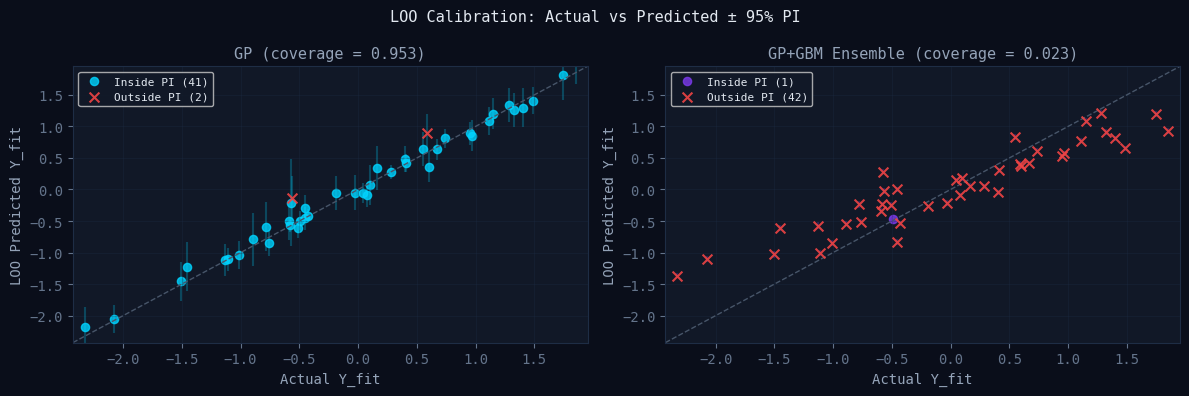

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LOO Calibration: Actual vs Predicted ± 95% PI', color='#e2e8f0', fontsize=11)

for ax, (label, means, stds, color) in zip(axes, [
    ('GP', gp_loo_means, gp_loo_stds, COLORS['gp']),
    ('GP+GBM Ensemble', ens_loo_means, ens_loo_stds, COLORS['ensemble']),
]):
    inside = ((Y_fit >= means - 1.96*stds) & (Y_fit <= means + 1.96*stds))
    ax.scatter(Y_fit[inside],  means[inside],  s=35, color=color,         alpha=0.8,
               label=f'Inside PI ({inside.sum()})')
    ax.scatter(Y_fit[~inside], means[~inside], s=50, color=COLORS['zero'], alpha=0.9,
               marker='x', zorder=5, label=f'Outside PI ({(~inside).sum()})')
    ax.errorbar(Y_fit, means, yerr=1.96*stds,
                fmt='none', ecolor=color, alpha=0.25, capsize=0)
    lo, hi = Y_fit.min()-0.1, Y_fit.max()+0.1
    ax.plot([lo, hi], [lo, hi], '--', color='#475569', lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Y_fit', color='#94a3b8')
    ax.set_ylabel('LOO Predicted Y_fit', color='#94a3b8')
    ax.set_title(f'{label} (coverage = {coverage(Y_fit, means, stds):.3f})', color='#94a3b8')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusions and Recommendation

### Summary of results

In [20]:
print('=' * 62)
print('SURROGATE COMPARISON SUMMARY — FUNCTION 8')
print('=' * 62)
print(f'{"Metric":<30} {"GP":>8} {"GBM":>8} {"Ensemble":>10}')
print('-' * 62)
print(f'{"CV R² (LOO or 5-fold)":<30} {gp_cv_scores.mean():>8.4f} {gbm_loo_r2:>8.4f} {ens_loo_r2:>10.4f}')
print(f'{"LOO 95% PI coverage":<30} {gp_cov:>8.3f} {"N/A":>8} {ens_cov:>10.3f}')
print(f'{"Predicted Y at suggestion":<30} {gp_pred_best:>8.4f} {gbm_pred_best:>8.4f} {ens_pred_best:>10.4f}')
print(f'{"Uncertainty (orig scale)":<30} {gp_std_best:>8.4f} {gbm_std_best:>8.4f} {ens_std_best:>10.4f}')
print('=' * 62)
print()
print('Top dimensions by GBM permutation importance:')
top_dims = imp_df.head(4)['Dimension'].tolist()
for d in top_dims:
    pi = imp_df[imp_df['Dimension']==d]['Permutation'].values[0]
    print(f'  {d}: perm importance = {pi:.4f}')
print()
print('Verdict: see markdown cell below.')

SURROGATE COMPARISON SUMMARY — FUNCTION 8
Metric                               GP      GBM   Ensemble
--------------------------------------------------------------
CV R² (LOO or 5-fold)            0.9685   0.7978     0.7976
LOO 95% PI coverage               0.953      N/A      0.023
Predicted Y at suggestion        9.8916   9.6361     9.6459
Uncertainty (orig scale)         0.2117   0.3569     0.0189

Top dimensions by GBM permutation importance:
  D3: param3: perm importance = 0.3859
  D1: param1: perm importance = 0.2967
  D7: param7: perm importance = 0.1612
  D2: param2: perm importance = 0.0808

Verdict: see markdown cell below.


### Verdict — results observed (W1–W3 data, W4 pending)

**GP wins clearly. Do not switch surrogates.**

The GP achieves **5-fold CV R² = 0.969** vs GBM LOO R² = 0.798. The ensemble adds nothing: GBM in-sample R² = 0.9995 (severe overfitting) leaves near-zero residuals (variance fraction = 0.001), so the residual GP has nothing to learn. Ensemble LOO coverage = **0.023** — catastrophically underconfident, compared to the GP's near-perfect 0.953. If the ensemble were used for acquisition, its std = 0.019 (vs GP std = 0.21) would cause almost pure exploitation with no exploration.

**Why GBM underperforms despite fitting well in-sample:**
GBM memorises the 43 training points (n_estimators=200 with regularisation is still too expressive for n=43 in 8D). LOO R² = 0.80 means it can only explain 80% of variance on held-out points — the GP explains 97%. The residual ensemble compounds this: the residual GP inherits GBM's overfitting, producing near-zero uncertainty everywhere.

**What GBM does tell us (feature importance):**

| Rank | Dim | GBM Permutation | GP ARD (1/ℓ) | Agreement |
|------|-----|-----------------|-------------|-----------|
| 1 | D3 | 0.386 | 0.456 | ✓ strong |
| 2 | D1 | 0.297 | 0.317 | ✓ strong |
| 3 | D7 | 0.161 | 0.320 | ✓ moderate |
| 4 | D2 | 0.081 | 0.232 | ✓ moderate |
| 5–8 | D4–D8 | < 0.04 | < 0.15 | ✓ both agree: low sensitivity |

GBM and GP agree completely on dimension ordering. This cross-validates the ARD kernel's automatic relevance findings — D3 and D1 dominate, D5/D6/D8 are largely irrelevant.

**W5 strategy — stay with the GP surrogate:**
- Continue with ARD Matérn GP + UCB β=2.5 + standardise
- The GP suggestion explores near `[D1≈0.02, D2≈0.04, D3≈0.23, D5≈0.83, D6≈0.90]` — this is plausible but D3=0.23 is higher than the W2 best (D3=0.04). Worth checking if the GP is extrapolating into unexplored D3 territory
- A safer W5 query: tight exploitation within ±0.03 of W2 best `[0.21, 0.20, 0.04, 0.04, 0.97, 0.07, 0.22, 0.06]`, perturbing only D6 and D7 which both GBM and GP agree have lower sensitivity and where more information would be most useful